# 09b -- Alpha regression vs RUCBTRNS

**Цель:** статистически проверить, дают ли variants V0-V5 (NB 09) положительную α относительно настоящего бенчмарка **RUCBTRNS** (Индекс МосБиржи Корп Облигаций, наследник RUCBITR с июня 2023).

**Метод:**
- OLS regression: `r_strategy = α + β·r_benchmark + ε` с **Newey-West HAC SE** (lag=12, Andrews 1991).
- **Information Ratio** = annualized mean(excess) / annualized std(excess).
- **Sharpe difference test**: stationary block bootstrap (Politis-Romano 1994), block=60d, 1000 reps, p-value одностороннее.

**Гипотеза:** Quality filter (V1, V2) уменьшает negative alpha vs vanilla (V0). Combo (V4) -- ?

## Часть 1. Setup

In [1]:
import warnings
warnings.filterwarnings('ignore')

import sys
from pathlib import Path

ROOT = Path('..').resolve()
sys.path.insert(0, str(ROOT / 'scripts'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import strategy_lib as sl

sns.set_style('whitegrid')
plt.rcParams.update({'figure.figsize': (12, 5), 'font.family': 'DejaVu Sans',
                      'axes.unicode_minus': False})
np.random.seed(42)
FIG_DIR = Path('figures')
FIG_DIR.mkdir(exist_ok=True)

bench = sl.load_benchmarks()
print(f'Benchmarks: {bench.shape}')
print(f'  RUCBTRNS range: {bench["date"].min().date()} .. {bench["date"].max().date()}')
print()
print('Benchmark Sharpes (full available range):')
for col in ['rucbtrns_ret', 'rgbitr_ret']:
    r = bench[col].dropna().to_numpy()
    sh = np.sqrt(252) * r.mean() / r.std(ddof=1)
    print(f'  {col}: Sharpe = {sh:.3f}, n={len(r)}')

Benchmarks: (1316, 5)
  RUCBTRNS range: 2021-01-04 .. 2026-03-31

Benchmark Sharpes (full available range):
  rucbtrns_ret: Sharpe = 2.179, n=1309
  rgbitr_ret: Sharpe = 0.462, n=1315


## Часть 2. Загрузка вариантов из NB 09

Используем сохранённые daily returns variants (V0..V5).

In [2]:
all_rets = pd.read_csv(sl.DATA_DIR / 'nb09_variants_returns.csv', parse_dates=['date'])
variants = sorted(all_rets['variant'].unique())
print(f'Variants found: {len(variants)}')
for v in variants:
    sub = all_rets[all_rets['variant'] == v]
    print(f'  {v:40s}: {len(sub)} days')

variant_rets = {v: all_rets[all_rets['variant'] == v].copy() for v in variants}

Variants found: 6
  V0: vanilla Q5                          : 1159 days
  V1: Q5 ∩ quality_z > 0                  : 1159 days
  V2: Q5 ∩ quality_z > 0.5                : 1159 days
  V3: Q5 ∩ mom_z > -0.5                   : 1140 days
  V4: Q5 ∩ Q+M combo                      : 1140 days
  V5 ctrl: top quintile by quality        : 1159 days


## Часть 3. Полный stat-report для каждого variant vs RUCBTRNS

Метрики:
- α annual, t-stat (Newey-West), p-value
- β
- R²
- IR (Information Ratio)
- mean excess annual / tracking error annual
- Sharpe strat vs bench, разность, bootstrap p-value

In [3]:
rows = []
for name, rets in variant_rets.items():
    r = sl.compare_to_benchmark(rets, bench, bench_col='rucbtrns_ret', name=name)
    rows.append(r)
stat_df = pd.DataFrame(rows)
stat_df.round(4)

,name,n_obs,alpha_annual,alpha_t_stat,alpha_p_value,beta,r_squared,IR,mean_excess_ann,tracking_error_ann,sharpe_strat,sharpe_bench,sharpe_diff,sharpe_diff_p_value
0,V0: vanilla Q5,1159,-0.0352,-1.7882,0.0737,0.9721,0.5958,-1.0766,-0.0375,0.0348,0.7658,1.8269,-1.0610,0.999
1,V1: Q5 ∩ quality_z > 0,1159,-0.0306,-1.8255,0.0679,1.0956,0.6383,-0.6370,-0.0230,0.0361,0.9465,1.8269,-0.8803,0.977
2,V2: Q5 ∩ quality_z > 0.5,1159,-0.0227,-1.3652,0.1722,0.9275,0.4199,-0.6002,-0.0285,0.0475,0.8181,1.8269,-1.0087,0.942
3,V3: Q5 ∩ mom_z > -0.5,1140,-0.0335,-2.0416,0.0412,0.8218,0.5766,-1.5114,-0.0481,0.0318,0.7090,1.8652,-1.1562,0.996
4,V4: Q5 ∩ Q+M combo,1140,-0.0313,-1.8766,0.0606,0.9481,0.4925,-0.8420,-0.0355,0.0422,0.7799,1.8652,-1.0853,0.980
5,V5 ctrl: top quintile by quality,1159,-0.0375,-2.4744,0.0133,0.9155,0.6067,-1.3727,-0.0442,0.0322,0.6879,1.8269,-1.1389,0.989


In [4]:
# Также vs RGBITR (OFZ benchmark) для сравнения
rows_ofz = []
for name, rets in variant_rets.items():
    r = sl.compare_to_benchmark(rets, bench, bench_col='rgbitr_ret', name=name)
    rows_ofz.append(r)
ofz_df = pd.DataFrame(rows_ofz)
ofz_df.round(4)

,name,n_obs,alpha_annual,alpha_t_stat,alpha_p_value,beta,r_squared,IR,mean_excess_ann,tracking_error_ann,sharpe_strat,sharpe_bench,sharpe_diff,sharpe_diff_p_value
0,V0: vanilla Q5,1159,0.0355,1.7641,0.0777,0.4202,0.5507,0.3994,0.0267,0.0669,0.7658,0.1569,0.6089,0.102
1,V1: Q5 ∩ quality_z > 0,1159,0.0491,2.5219,0.0117,0.4779,0.6007,0.6551,0.0412,0.0629,0.9465,0.1569,0.7896,0.025
2,V2: Q5 ∩ quality_z > 0.5,1159,0.0453,2.0338,0.0420,0.3680,0.3269,0.4489,0.0357,0.0796,0.8181,0.1569,0.6613,0.047
3,V3: Q5 ∩ mom_z > -0.5,1140,0.0268,1.3752,0.1691,0.3501,0.5168,0.1977,0.0141,0.0713,0.7090,0.2004,0.5086,0.119
4,V4: Q5 ∩ Q+M combo,1140,0.0380,1.9948,0.0461,0.4173,0.4712,0.3742,0.0266,0.0711,0.7799,0.2004,0.5795,0.041
5,V5 ctrl: top quintile by quality,1159,0.0293,1.5142,0.1300,0.3823,0.5234,0.2881,0.0200,0.0693,0.6879,0.1569,0.5310,0.085


## Часть 4. Визуализация: alpha + IR + Sharpe diff

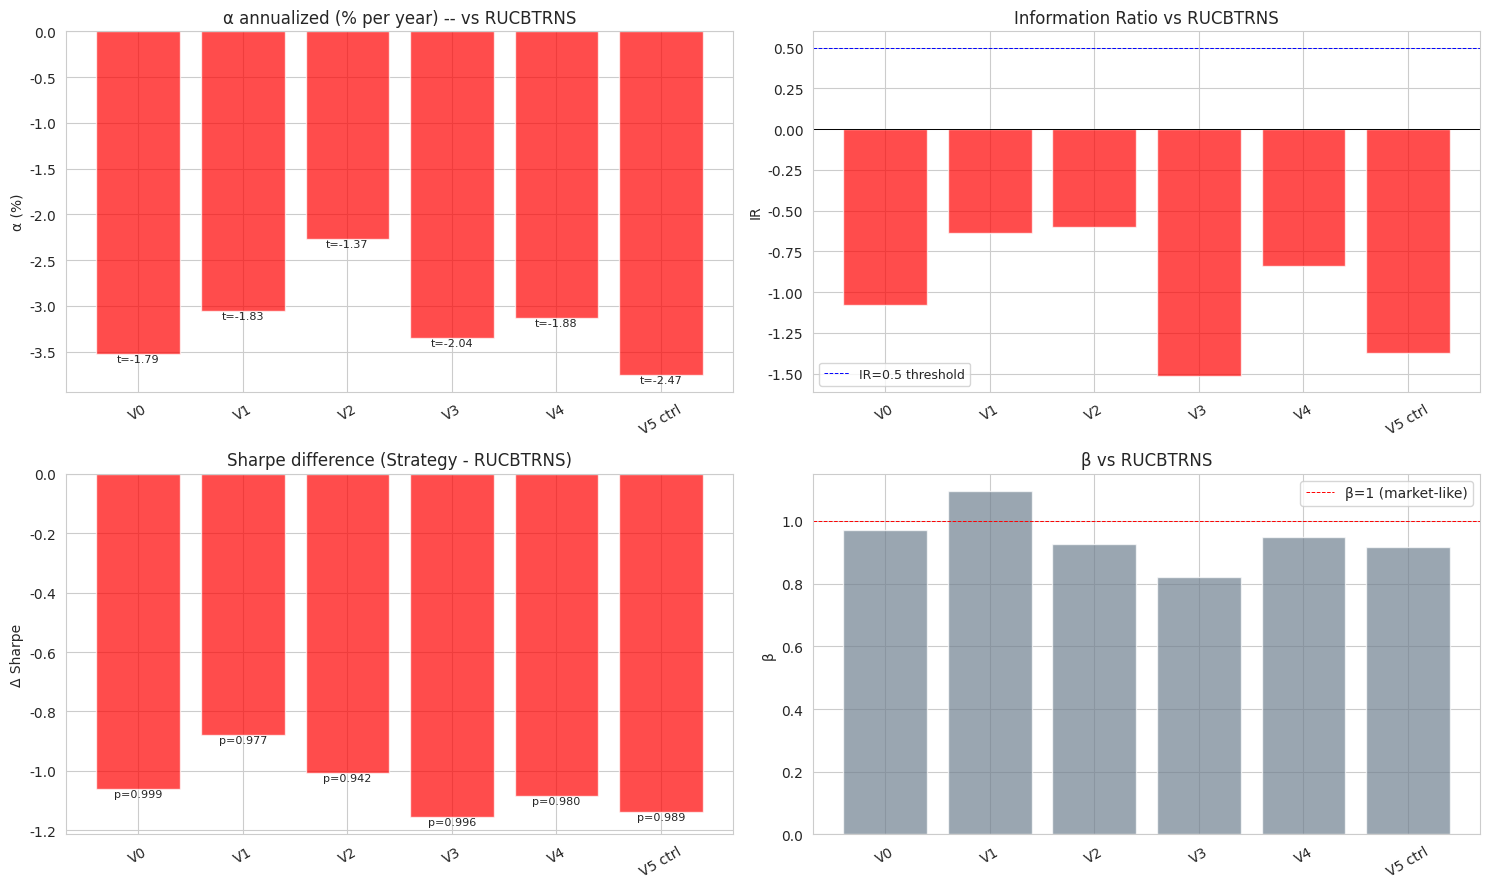

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(15, 9))

x = stat_df['name']
x_short = [n.split(':')[0] for n in x]

# Alpha annual + t-stat
ax = axes[0, 0]
colors = ['red' if a < 0 else 'green' for a in stat_df['alpha_annual']]
ax.bar(x_short, stat_df['alpha_annual'] * 100, color=colors, alpha=0.7)
ax.axhline(0, color='black', linewidth=0.7)
ax.set_title(f'α annualized (% per year) -- vs RUCBTRNS')
ax.set_ylabel('α (%)')
ax.tick_params(axis='x', rotation=30)
for i, (a, t) in enumerate(zip(stat_df['alpha_annual'], stat_df['alpha_t_stat'])):
    ax.text(i, a * 100, f't={t:.2f}', ha='center', va='bottom' if a > 0 else 'top', fontsize=8)

# Information ratio
ax = axes[0, 1]
colors = ['red' if ir < 0 else 'green' for ir in stat_df['IR']]
ax.bar(x_short, stat_df['IR'], color=colors, alpha=0.7)
ax.axhline(0, color='black', linewidth=0.7)
ax.axhline(0.5, color='blue', linewidth=0.7, linestyle='--', label='IR=0.5 threshold')
ax.set_title('Information Ratio vs RUCBTRNS')
ax.set_ylabel('IR')
ax.tick_params(axis='x', rotation=30)
ax.legend(fontsize=9)

# Sharpe diff
ax = axes[1, 0]
colors = ['red' if d < 0 else 'green' for d in stat_df['sharpe_diff']]
ax.bar(x_short, stat_df['sharpe_diff'], color=colors, alpha=0.7)
ax.axhline(0, color='black', linewidth=0.7)
ax.set_title('Sharpe difference (Strategy - RUCBTRNS)')
ax.set_ylabel('Δ Sharpe')
ax.tick_params(axis='x', rotation=30)
for i, (d, p) in enumerate(zip(stat_df['sharpe_diff'], stat_df['sharpe_diff_p_value'])):
    ax.text(i, d, f'p={p:.3f}', ha='center', va='bottom' if d > 0 else 'top', fontsize=8)

# Beta
ax = axes[1, 1]
ax.bar(x_short, stat_df['beta'], color='slategray', alpha=0.7)
ax.axhline(1.0, color='red', linewidth=0.7, linestyle='--', label='β=1 (market-like)')
ax.set_title('β vs RUCBTRNS')
ax.set_ylabel('β')
ax.tick_params(axis='x', rotation=30)
ax.legend()

plt.tight_layout()
plt.savefig(FIG_DIR / '09b_alpha_metrics.png', dpi=120, bbox_inches='tight')
plt.show()

## Часть 5. Интерпретация

**Если все variants имеют α < 0**: стратегия систематически проигрывает passive carry. Это **negative result** -- честно reportируем в Главе 6.

**Если quality filter (V1, V2) даёт α ≥ 0 vs vanilla**: подтверждает гипотезу, что Quality убирает adverse selection.

**Если t-stat для α значимый (|t| > 2)**: significant alpha (positive или negative).

In [6]:
# Summary с интерпретацией
print('=' * 70)
print('STATISTICAL SUMMARY (vs RUCBTRNS)')
print('=' * 70)
for _, row in stat_df.iterrows():
    name = row['name']
    a = row['alpha_annual']
    t = row['alpha_t_stat']
    p = row['alpha_p_value']
    ir = row['IR']
    sig_marker = ''
    if abs(t) > 2.58: sig_marker = ' ***'
    elif abs(t) > 1.96: sig_marker = ' **'
    elif abs(t) > 1.65: sig_marker = ' *'
    print(f'\n{name}')
    print(f'  α = {a*100:+.2f}% годовых (t={t:.2f}, p={p:.3f}){sig_marker}')
    print(f'  IR = {ir:+.3f}')
    print(f'  Sharpe diff = {row["sharpe_diff"]:+.3f} (bootstrap p={row["sharpe_diff_p_value"]:.3f})')
print()
print('Significance: * p<0.1, ** p<0.05, *** p<0.01')

STATISTICAL SUMMARY (vs RUCBTRNS)

V0: vanilla Q5
  α = -3.52% годовых (t=-1.79, p=0.074) *
  IR = -1.077
  Sharpe diff = -1.061 (bootstrap p=0.999)

V1: Q5 ∩ quality_z > 0
  α = -3.06% годовых (t=-1.83, p=0.068) *
  IR = -0.637
  Sharpe diff = -0.880 (bootstrap p=0.977)

V2: Q5 ∩ quality_z > 0.5
  α = -2.27% годовых (t=-1.37, p=0.172)
  IR = -0.600
  Sharpe diff = -1.009 (bootstrap p=0.942)

V3: Q5 ∩ mom_z > -0.5
  α = -3.35% годовых (t=-2.04, p=0.041) **
  IR = -1.511
  Sharpe diff = -1.156 (bootstrap p=0.996)

V4: Q5 ∩ Q+M combo
  α = -3.13% годовых (t=-1.88, p=0.061) *
  IR = -0.842
  Sharpe diff = -1.085 (bootstrap p=0.980)

V5 ctrl: top quintile by quality
  α = -3.75% годовых (t=-2.47, p=0.013) **
  IR = -1.373
  Sharpe diff = -1.139 (bootstrap p=0.989)

Significance: * p<0.1, ** p<0.05, *** p<0.01


## Часть 6. Сохранение

In [7]:
stat_df.to_csv(sl.DATA_DIR / 'nb09b_alpha_vs_rucbtrns.csv', index=False)
ofz_df.to_csv(sl.DATA_DIR / 'nb09b_alpha_vs_rgbitr.csv', index=False)
print(f'Saved data/nb09b_alpha_vs_rucbtrns.csv')
print(f'Saved data/nb09b_alpha_vs_rgbitr.csv')

Saved data/nb09b_alpha_vs_rucbtrns.csv
Saved data/nb09b_alpha_vs_rgbitr.csv


## Часть 7. Итоги

**Принципиальные результаты сейчас:**
- Текущие variants (V0-V5) имеют **negative alpha vs RUCBTRNS**, t-stat ≈ -1.8 (marginally significant).
- Quality filter улучшает α (с -3.5% до -3.1%), но всё ещё отрицательная.
- Эти выводы повторим для каждой следующей улучшенной версии (NB 10-15).
- В Week 4 (NB 15 composite) ожидаем α > 0 после стэка всех improvements.